# Introducing the Keras Functional API

**Learning Objectives**
1. Understand the Keras Functional API for flexible model building.
2. Implement Wide & Deep models (memorization + generalization).
3. Use Keras preprocessing layers (`Discretization`, `HashedCrossing`, `Embedding`).

## Introduction

In the last notebook, we learned about the Keras Sequential API. The [Keras Functional API](https://keras.io/guides/functional_api/) provides an alternative way of building models that is more flexible. With the Functional API, we can build models with more complex topologies, multiple input or output layers, shared layers or non-sequential data flows (e.g. residual layers).

In this notebook, we'll use Functional API and preprocessing layers to build a Wide & Deep model.

### Wide & Deep Models
Recall that the idea behind Wide & Deep models is to join the two methods of learning through memorization and generalization by making a wide linear model and a deep learning model to accommodate both. You can have a look at the original research paper here: [Wide & Deep Learning for Recommender Systems](https://arxiv.org/abs/1606.07792).

<img src='assets/wide_deep.png' width='80%'>
<sup>(image: https://ai.googleblog.com/2016/06/wide-deep-learning-better-together-with.html)</sup>

The wide part of the model is associated with the memory element. In this case, we train a linear model with a wide set of crossed features and learn the correlation of this related data with the assigned label. The deep part of the model is associated with the generalization element where we use embedding vectors for features. The best embeddings are then learned through the training process. While both of these methods can work well alone, Wide & Deep models excel by combining these techniques together. 

## Setup
Start by importing the necessary libraries for this lab.

In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import datetime
import shutil

import keras
import numpy as np
import pandas as pd
import tensorflow as tf
from keras import Model
from keras.callbacks import TensorBoard
from keras.layers import (
    CategoryEncoding,
    Concatenate,
    Dense,
    Discretization,
    Embedding,
    Flatten,
    HashedCrossing,
    Input,
)
from keras.metrics import RootMeanSquaredError
from matplotlib import pyplot as plt

2026-02-26 00:46:07.314121: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772066767.340419   56362 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772066767.348446   56362 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-26 00:46:07.376499: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
%matplotlib inline

### Load raw data 

We will use the taxifare dataset, using the CSV files that we created in the first notebook of this sequence. Those files have been saved into `../data`.

In [3]:
!ls -l ../data/*.csv

-rw-r--r-- 1 jupyter jupyter 123675 Feb 25 05:35 ../data/taxi-test.csv
-rw-r--r-- 1 jupyter jupyter 579140 Feb 25 05:35 ../data/taxi-train.csv
-rw-r--r-- 1 jupyter jupyter 399647 Feb 25 05:35 ../data/taxi-valid.csv


### Use tf.data to read the CSV files

We wrote these functions for reading data from the CSV files above in the [previous notebook](2_dataset_api.ipynb).

The `tf.data` API efficiently loads and preprocesses data. 
- `parse_csv`: Parses a CSV row into features and a label. Features are returned as a tuple for Functional API compatibility with multiple inputs.
- `create_dataset`: Builds a `tf.data.Dataset` from CSV files, including mapping `parse_csv`, repeating, shuffling (for training), and batching.

In [4]:
def parse_csv(row):
    ds = tf.strings.split(row, ",")
    # Label: fare_amount
    label = tf.strings.to_number(ds[0])
    # Features: pickup_longitude, pickup_latitude, dropoff_longitude, dropoff_latitude
    feature = tf.strings.to_number(ds[2:6])  # use some features only
    # Passing feature in tuple so that we can handle them separately.
    return (feature[0], feature[1], feature[2], feature[3]), label


def create_dataset(pattern, batch_size, mode="eval"):
    ds = tf.data.TextLineDataset(pattern).skip(1)
    ds = ds.map(parse_csv).repeat()
    if mode == "train":
        ds = ds.shuffle(buffer_size=1000)
    ds = ds.batch(batch_size, drop_remainder=True)
    return ds

## Build a Wide & Deep Model with the Keras Functional API

We'll construct a Wide & Deep model, which has two parts:
1.  **Wide Path:** For memorizing specific feature interactions (often using categorical/crossed features).
2.  **Deep Path:** For generalizing patterns (often using numerical features/embeddings through a DNN).
The outputs are then combined for prediction. The Functional API handles this complex structure.

### Define Input Layers

Using the Functional API, each input feature gets its own [`keras.Input` layer](https://keras.io/api/layers/core_layers/input/). These define the entry points for data.
We create `Input` objects for our four coordinate features, specifying their `name`, `shape` (scalar), and `dtype`.

In [5]:
INPUT_COLS = [
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
]

inputs = {
    colname: Input(name=colname, shape=(1,), dtype="float32")
    for colname in INPUT_COLS
}

### Define Preprocessing Logic

Next, we define preprocessing for our features.
1.  **Bucketization:** `Discretization` layer converts continuous latitude/longitude inputs into categorical features by assigning them to predefined buckets (`latbuckets`, `lonbuckets`).
2.  **Feature Crossing:** `HashedCrossing` layer combines these bucketized features to create interaction features (e.g., pickup location, dropoff location, and pickup-dropoff interaction). This is useful for the wide part of the model.

With the Functional API, you can define each connection independently, which allows for more intricate model architectures.

In [6]:
dnn_hidden_units = [32, 8]
NBUCKETS = 16

# Define Bucketization boundaries
latbuckets = np.linspace(start=40.5, stop=41.0, num=NBUCKETS).tolist()
lonbuckets = np.linspace(start=-74.2, stop=-73.7, num=NBUCKETS).tolist()

# Bucketization with Discretization layer
plon = Discretization(lonbuckets, name="plon_bkt")(inputs["pickup_longitude"])
plat = Discretization(latbuckets, name="plat_bkt")(inputs["pickup_latitude"])
dlon = Discretization(lonbuckets, name="dlon_bkt")(inputs["dropoff_longitude"])
dlat = Discretization(latbuckets, name="dlat_bkt")(inputs["dropoff_latitude"])

# Feature Cross with HashedCrossing layer
p_fc = HashedCrossing(num_bins=(NBUCKETS + 1) ** 2, name="p_fc")((plon, plat))
d_fc = HashedCrossing(num_bins=(NBUCKETS + 1) ** 2, name="d_fc")((dlon, dlat))
pd_fc = HashedCrossing(num_bins=(NBUCKETS + 1) ** 4, name="pd_fc")((p_fc, d_fc))

### Build the Deep Path

The deep path handles generalization:
1.  The `pd_fc` crossed feature is embedded using an `Embedding` layer to create dense vector representations.
2.  These embeddings are concatenated with the original numerical input coordinates.
3.  The result is passed through a stack of `Dense` layers with ReLU activation.

In [15]:
# Embedding with Embedding layer
pd_embed = Embedding(
    input_dim=(NBUCKETS + 1) ** 6, output_dim=10, name="pd_embed" # test 4->6 #
)(pd_fc)

# Concatenate and define inputs for deep network
deep = Concatenate(name="deep_input")(
    [
        inputs["pickup_longitude"],
        inputs["pickup_latitude"],
        inputs["dropoff_longitude"],
        inputs["dropoff_latitude"],
        Flatten(name="flatten_embedding")(pd_embed),
    ]
)

# Add hidden Dense layers
for i, num_nodes in enumerate(dnn_hidden_units, start=1):
    deep = Dense(num_nodes, activation="relu", name=f"hidden_{i}")(deep)

### Build the Wide Path

The wide path handles memorization:
1.  The crossed features (`p_fc`, `d_fc`, `pd_fc`) are one-hot encoded using the `CategoryEncoding` layer.
2.  These one-hot encoded features are then concatenated to form the input for the wide part of the model.

In [16]:
# Onehot Encoding with CategoryEncoding layer
p_onehot = CategoryEncoding(num_tokens=(NBUCKETS + 1) ** 2, name="p_onehot")(
    p_fc
)
d_onehot = CategoryEncoding(num_tokens=(NBUCKETS + 1) ** 2, name="d_onehot")(
    d_fc
)
pd_onehot = CategoryEncoding(num_tokens=(NBUCKETS + 1) ** 4, name="pd_onehot")(
    pd_fc
)

# Concatenate and define inputs for wide network
wide = Concatenate(name="wide_input")([p_onehot, d_onehot, pd_onehot])

### Combine Wide and Deep Paths

The outputs of the `deep` and `wide` paths are concatenated. This combined tensor is then fed into a final `Dense` layer with one unit (and no activation for regression) to produce the prediction.

In [17]:
# Concatenate wide & deep networks
concat = Concatenate(name="concatenate")([deep, wide])

# Define the final output layer
output = Dense(1, activation=None, name="output")(concat)

### Instantiate and Compile the Model

In Functional API, `keras.Model` is used to define the model by specifying its `inputs` (our dictionary of `Input` layers) and `outputs` (the final `Dense` layer).

In [18]:
model = Model(inputs=list(inputs.values()), outputs=output)

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=[RootMeanSquaredError()],
)

In Functional API, `keras.utils.plot_model` generates a diagram of the model structure.

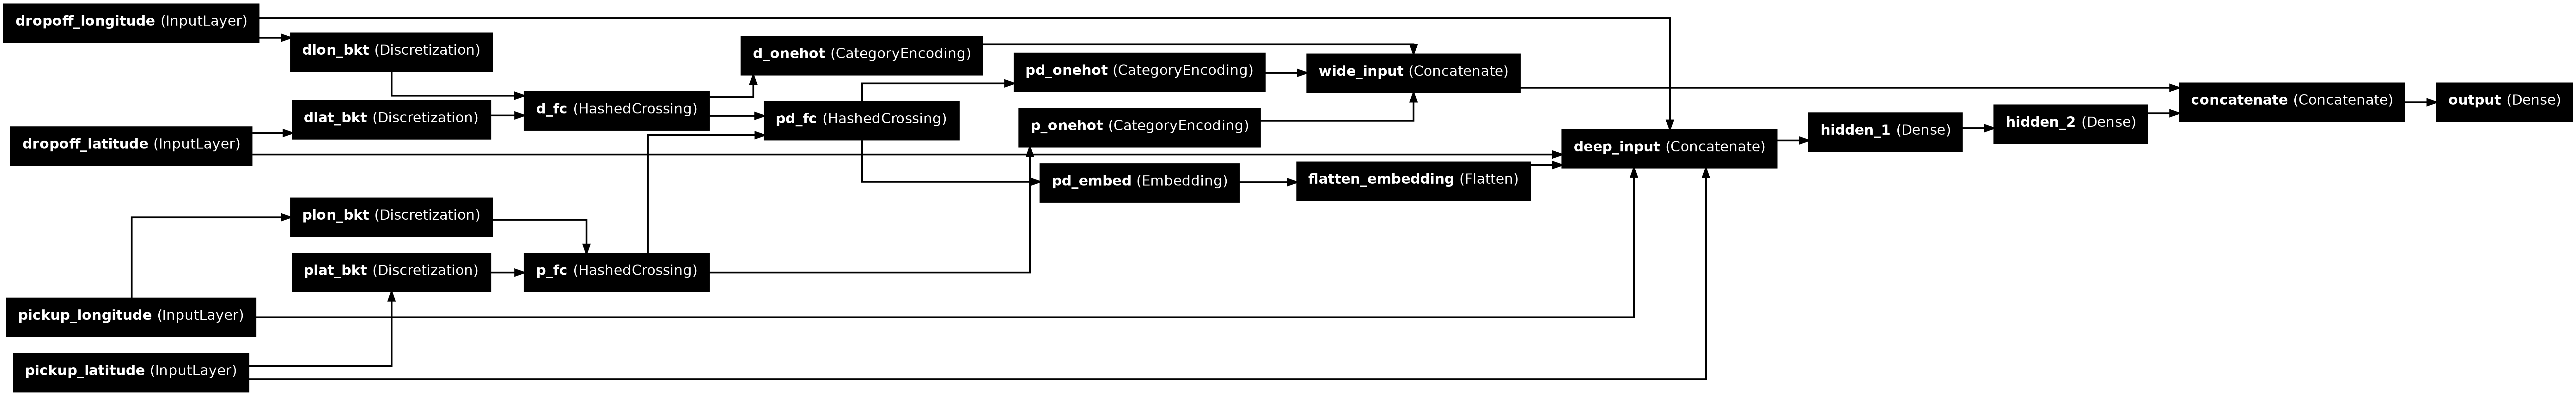

In [19]:
keras.utils.plot_model(model, show_layer_names=True, rankdir="LR")

## Train the Wide & Deep Model
Next, we'll set up our training variables, create our datasets for training and validation, and train our model.

(We refer you to the blog post [ML Design Pattern #3: Virtual Epochs](https://medium.com/google-cloud/ml-design-pattern-3-virtual-epochs-f842296de730) for further details on why we express the training in terms of `NUM_TRAIN_EXAMPLES` and `NUM_EVALS` and why, in this training code, the number of epochs is really equal to the number of evaluations we perform.)

In [20]:
BATCH_SIZE = 64
NUM_TRAIN_EXAMPLES = 10000 * 10  # training dataset will repeat, wrap around
NUM_EVALS = 10  # how many times to evaluate
NUM_EVAL_EXAMPLES = 1000  # enough to get a reasonable sample

trainds = create_dataset(
    pattern="../data/taxi-train.csv", batch_size=BATCH_SIZE, mode="train"
)

evalds = create_dataset(
    pattern="../data/taxi-valid.csv", batch_size=BATCH_SIZE, mode="eval"
).take(NUM_EVAL_EXAMPLES // BATCH_SIZE)

In [21]:
%%time
steps_per_epoch = NUM_TRAIN_EXAMPLES // (BATCH_SIZE * NUM_EVALS)

OUTDIR = "./taxi_trained"
shutil.rmtree(path=OUTDIR, ignore_errors=True)  # start fresh each time

history = model.fit(
    x=trainds,
    steps_per_epoch=steps_per_epoch,
    epochs=NUM_EVALS,
    validation_data=evalds,
    callbacks=[TensorBoard(OUTDIR)],
)

Epoch 1/10


/home/jupyter/asl-ml-immersion/asl_core/.venv/lib/python3.12/site-packages/tensorflow/python/framework/indexed_slices.py:446: UserWarning: Converting sparse IndexedSlices to a dense Tensor with 241375690 elements. This may consume a large amount of memory.
  warnings.warn(


156/156 ━━━━━━━━━━━━━━━━━━━━ 378s 2s/step - loss: 110.4872 - root_mean_squared_error: 10.5113 - val_loss: 96.0422 - val_root_mean_squared_error: 9.8001
Epoch 2/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 424s 3s/step - loss: 90.3750 - root_mean_squared_error: 9.5066 - val_loss: 87.9060 - val_root_mean_squared_error: 9.3758
Epoch 3/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 362s 2s/step - loss: 80.9178 - root_mean_squared_error: 8.9954 - val_loss: 72.7554 - val_root_mean_squared_error: 8.5297
Epoch 4/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 272s 2s/step - loss: 56.5185 - root_mean_squared_error: 7.5179 - val_loss: 58.1196 - val_root_mean_squared_error: 7.6236
Epoch 5/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 241s 2s/step - loss: 48.9754 - root_mean_squared_error: 6.9982 - val_loss: 50.4392 - val_root_mean_squared_error: 7.1021
Epoch 6/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 310s 2s/step - loss: 41.8356 - root_mean_squared_error: 6.4680 - val_loss: 47.0334 - val_root_mean_squared_error: 6.8581
Epoch 7/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 294

Just as before, we can examine the history to see how the RMSE changes through training on the training set and validation set. 

<Axes: >

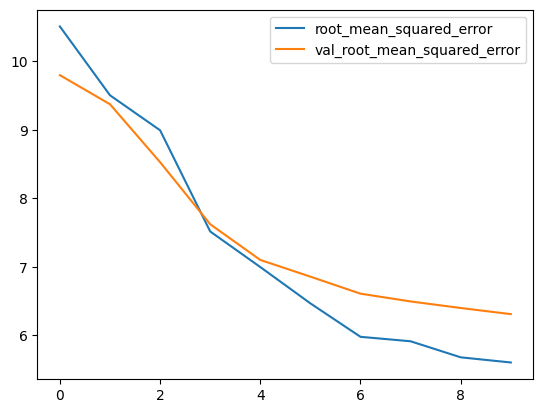

In [22]:
RMSE_COLS = ["root_mean_squared_error", "val_root_mean_squared_error"]

pd.DataFrame(history.history)[RMSE_COLS].plot()

Copyright 2025 Google Inc. Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0 Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.